In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature







from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


In [24]:
#import sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(time = slice('1991', '2023'))
clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
#ocean_mask = ~sst.isel(time = 1).sst.isnull()
sst = sst.groupby('time.month') - clim


In [25]:
sst = sst.sel(time = slice('2022-08', '2022-10')).mean('time')

/tmp/ipykernel_1922460/180344643.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


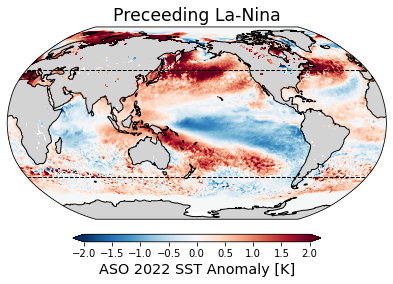

In [29]:
import matplotlib.gridspec as gridspec

# Projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.3, wspace=0.1)

# Define projections
proj = {'projection': projection}

# Top center plot (Residual Correlation) — span both columns
ax0 = fig.add_subplot(gs[0, :], **proj)




# Projection
projection = ccrs.Robinson(central_longitude=180)


# --- 1. Residual Correlation ---
ax = ax0
cbar = ax.pcolormesh(sst.lon, sst.lat, sst.sst, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-2, vmax=2)
cb = fig.colorbar(cbar, ax=ax0, orientation='horizontal', fraction=0.035, pad=0.07, aspect=30, extend='both')
cb.set_label('ASO 2022 SST Anomaly [K]')

ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title('Preceeding La-Nina')
ax.set_xticks([])
ax.set_yticks([])



# Final layout
for ax in [ax0]: 
    # Get full longitude range from the data
    lon_min = ax.get_extent(crs=ccrs.PlateCarree())[0]
    lon_max = ax.get_extent(crs=ccrs.PlateCarree())[1]
    lons = np.linspace(lon_min, lon_max, 100)

    # Add ±45° horizontal lines
    ax.plot(lons, np.full_like(lons, 45), transform=ccrs.PlateCarree(),
            color='black', linestyle='--', linewidth=1, zorder=5)
    ax.plot(lons, np.full_like(lons, -45), transform=ccrs.PlateCarree(),
            color='black', linestyle='--', linewidth=1, zorder=5)


plt.tight_layout()
plt.savefig('Figures/temp.png', dpi = 300)
plt.show()
